In [52]:
import pandas as pd

df_full = pd.read_csv("df.csv")
df_lab = pd.read_csv("df_lab.csv")
df_natural = pd.read_csv("df_natural.csv")

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# EDA on the full dataframe (lab-grown and natural diamonds)

All EDA charts use price_2025 to ensure pricing comparisons reflect a common timeline, unless stated otherwise. Brilliant Earth prices were manually adjusted from 2018 levels using an estimated index, so slight uncertainty exists in those entries.

In [54]:
df = df_full.copy()
df.head()

,retailer,diamond_type,shape,polish,symmetry,fluorescence,retail_price,price_carat,qualityScore,qualityMaxScore,cut,color,clarity,carat,report,price_2025,price_carat_2025
0,avignon diamonds,lab,round,Excellent,Excellent,NaN,2842.00,1359.81,18.0,18.0,super ideal,E,VVS2,2.09,IGI,2842.00,1359.81
1,cirrus gems,lab,round,Excellent,Excellent,NaN,2797.00,1338.28,18.0,18.0,super ideal,E,VVS2,2.09,IGI,2797.00,1338.28
2,ember star,lab,round,Excellent,Excellent,NaN,2794.11,1336.89,18.0,18.0,super ideal,E,VVS2,2.09,IGI,2794.11,1336.89
3,jane brear,lab,round,Excellent,Excellent,NaN,2805.00,1342.11,18.0,18.0,super ideal,E,VVS2,2.09,IGI,2805.00,1342.11
4,kiyo,lab,round,Excellent,Excellent,NaN,2789.00,1334.45,18.0,18.0,super ideal,E,VVS2,2.09,IGI,2789.00,1334.45


Distribution of Numeric Features

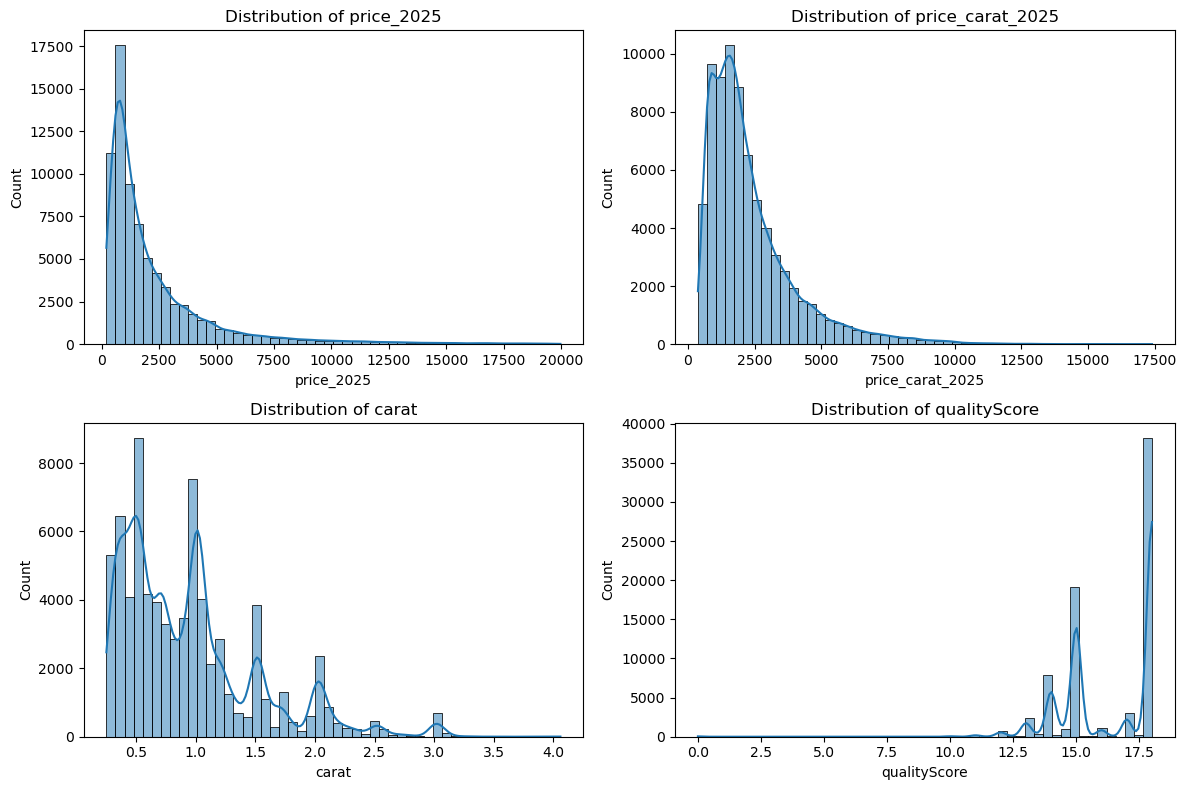

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top left
sns.histplot(df['price_2025'], kde=True, bins=50, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of price_2025')
axes[0, 0].set_xlabel('price_2025')

# Top right
sns.histplot(df['price_carat_2025'], kde=True, bins=50, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of price_carat_2025')
axes[0, 1].set_xlabel('price_carat_2025')

# Bottom left
sns.histplot(df['carat'], kde=True, bins=50, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of carat')
axes[1, 0].set_xlabel('carat')

# Bottom right
sns.histplot(df['qualityScore'], kde=True, bins=50, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of qualityScore')
axes[1, 1].set_xlabel('qualityScore')

plt.tight_layout()
plt.show()

Distribution of the log transformation on price 

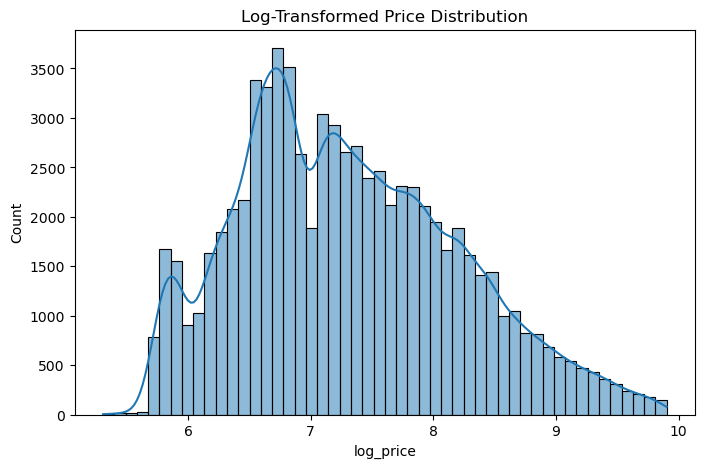

In [56]:
import numpy as np
df['log_price'] = np.log1p(df['price_2025'])

plt.figure(figsize=(8, 5))
sns.histplot(df['log_price'], kde=True, bins=50)
plt.title("Log-Transformed Price Distribution")
plt.show()

Count of Categorical Variables

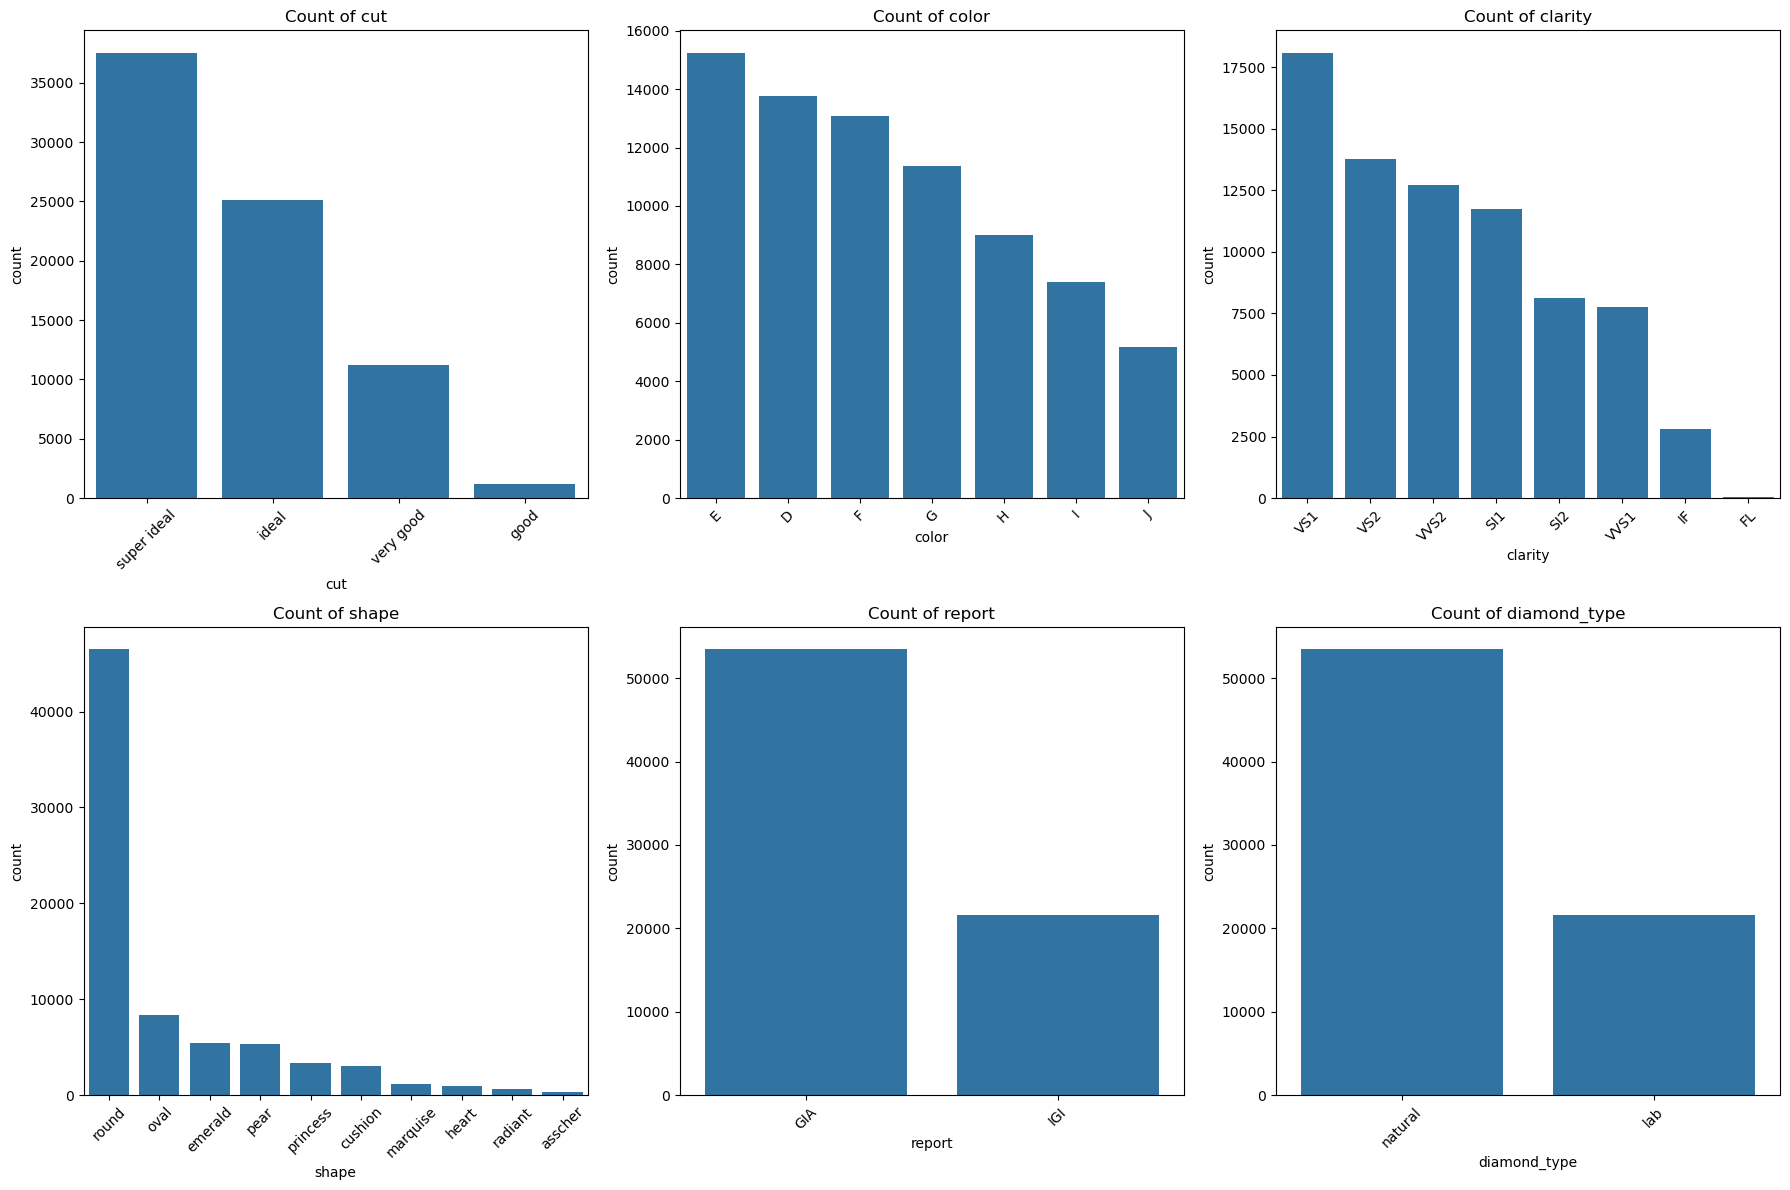

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Cut
sns.countplot(data=df, x='cut', order=df['cut'].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title('Count of cut')
axes[0, 0].tick_params(axis='x', rotation=45)

# Color
sns.countplot(data=df, x='color', order=df['color'].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title('Count of color')
axes[0, 1].tick_params(axis='x', rotation=45)

# Clarity
sns.countplot(data=df, x='clarity', order=df['clarity'].value_counts().index, ax=axes[0, 2])
axes[0, 2].set_title('Count of clarity')
axes[0, 2].tick_params(axis='x', rotation=45)

# Shape
sns.countplot(data=df, x='shape', order=df['shape'].value_counts().index, ax=axes[1, 0])
axes[1, 0].set_title('Count of shape')
axes[1, 0].tick_params(axis='x', rotation=45)

# Report
sns.countplot(data=df, x='report', order=df['report'].value_counts().index, ax=axes[1, 1])
axes[1, 1].set_title('Count of report')
axes[1, 1].tick_params(axis='x', rotation=45)

# Diamond Type
sns.countplot(data=df, x='diamond_type', order=df['diamond_type'].value_counts().index, ax=axes[1, 2])
axes[1, 2].set_title('Count of diamond_type')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Price by Category (Boxplots)

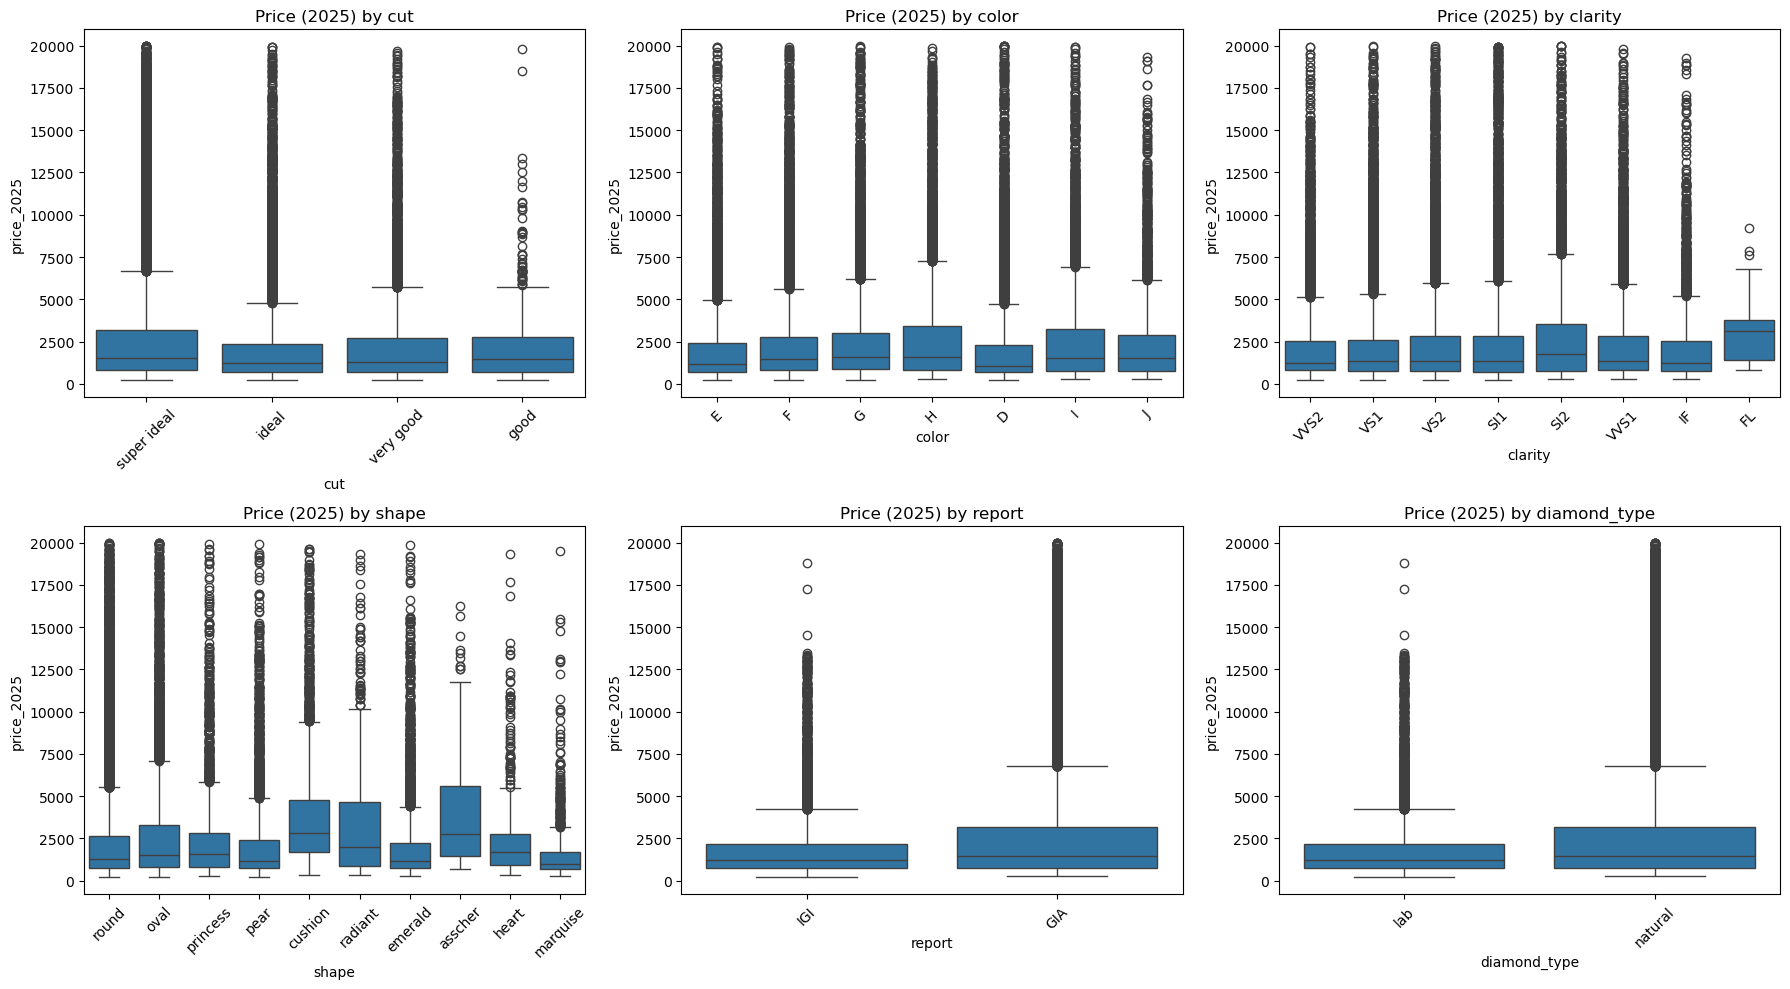

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# cut
sns.boxplot(data=df, x='cut', y='price_2025', ax=axes[0, 0])
axes[0, 0].set_title('Price (2025) by cut')
axes[0, 0].tick_params(axis='x', rotation=45)

# color
sns.boxplot(data=df, x='color', y='price_2025', ax=axes[0, 1])
axes[0, 1].set_title('Price (2025) by color')
axes[0, 1].tick_params(axis='x', rotation=45)

# clarity
sns.boxplot(data=df, x='clarity', y='price_2025', ax=axes[0, 2])
axes[0, 2].set_title('Price (2025) by clarity')
axes[0, 2].tick_params(axis='x', rotation=45)

# shape
sns.boxplot(data=df, x='shape', y='price_2025', ax=axes[1, 0])
axes[1, 0].set_title('Price (2025) by shape')
axes[1, 0].tick_params(axis='x', rotation=45)

# report
sns.boxplot(data=df, x='report', y='price_2025', ax=axes[1, 1])
axes[1, 1].set_title('Price (2025) by report')
axes[1, 1].tick_params(axis='x', rotation=45)

# diamond_type
sns.boxplot(data=df, x='diamond_type', y='price_2025', ax=axes[1, 2])
axes[1, 2].set_title('Price (2025) by diamond_type')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Correlation Matrix (Numerical Variables)

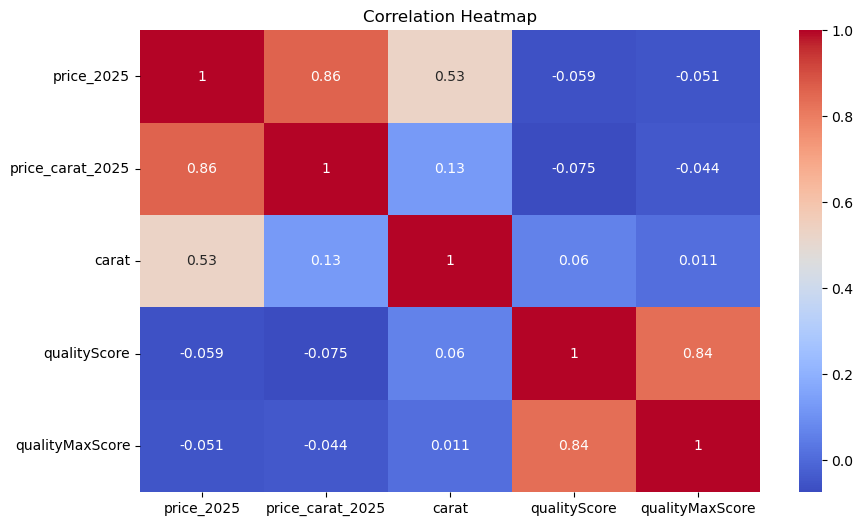

In [59]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[['price_2025', 'price_carat_2025', 'carat', 'qualityScore', 'qualityMaxScore']].corr(), 
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Outlier Summary

In [60]:
# Check extreme values
df[['price_2025', 'price_carat_2025']].describe(percentiles=[.01, .25, .5, .75, .95, .99])

,price_2025,price_carat_2025
count,75034.000000,75034.000000
mean,2320.768876,2341.639307
std,2648.040851,1688.944711
min,200.590000,371.260000
1%,316.410000,504.873100
25%,764.000000,1211.517500
50%,1363.000000,1861.835000
75%,2782.315000,2910.000000
95%,7679.000000,5803.178500
99%,13931.010000,8630.000000


# EDA on the lab-grown diamonds df vs natural diamonds

Distribution of Numeric Features

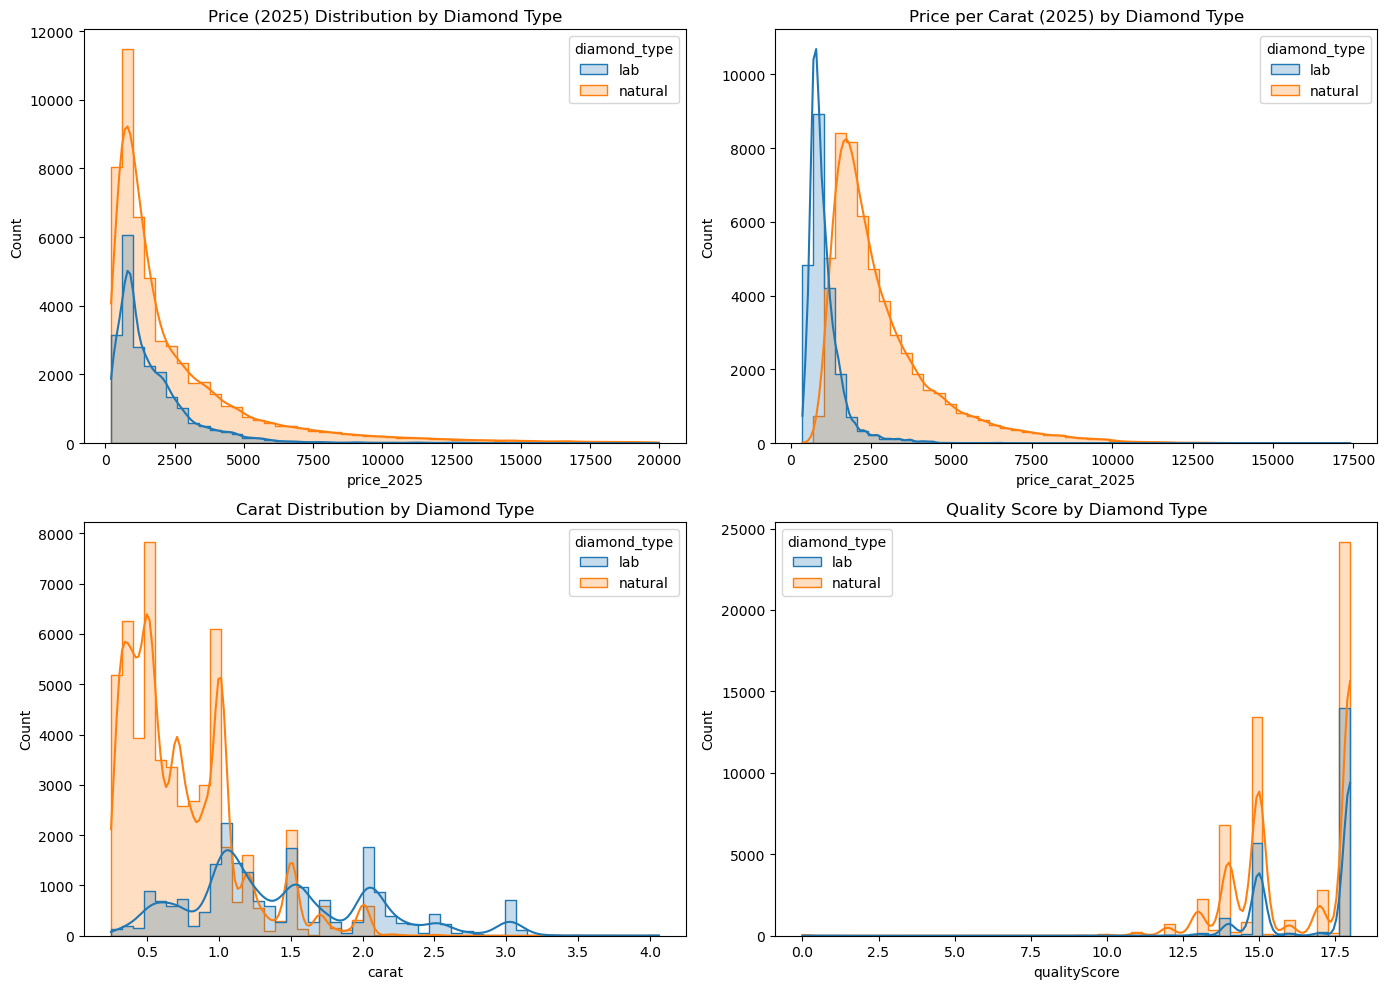

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: price_2025
sns.histplot(data=df, x='price_2025', hue='diamond_type', kde=True, bins=50, ax=axes[0, 0], element='step')
axes[0, 0].set_title('Price (2025) Distribution by Diamond Type')
axes[0, 0].set_xlabel('price_2025')

# Top right: price_carat_2025
sns.histplot(data=df, x='price_carat_2025', hue='diamond_type', kde=True, bins=50, ax=axes[0, 1], element='step')
axes[0, 1].set_title('Price per Carat (2025) by Diamond Type')
axes[0, 1].set_xlabel('price_carat_2025')

# Bottom left: carat
sns.histplot(data=df, x='carat', hue='diamond_type', kde=True, bins=50, ax=axes[1, 0], element='step')
axes[1, 0].set_title('Carat Distribution by Diamond Type')
axes[1, 0].set_xlabel('carat')

# Bottom right: qualityScore
sns.histplot(data=df, x='qualityScore', hue='diamond_type', kde=True, bins=50, ax=axes[1, 1], element='step')
axes[1, 1].set_title('Quality Score by Diamond Type')
axes[1, 1].set_xlabel('qualityScore')

plt.tight_layout()
plt.show()

Distribution of the log transformation on price 

<Axes: xlabel='log_price_2025', ylabel='Count'>

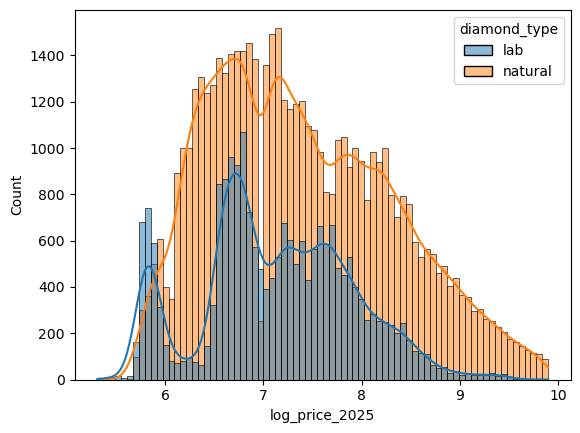

In [62]:
df['log_price_2025'] = np.log1p(df['price_2025'])

# Then use this in boxplots or histograms
sns.histplot(data=df, x='log_price_2025', hue='diamond_type', kde=True)

Boxplots by Key Features

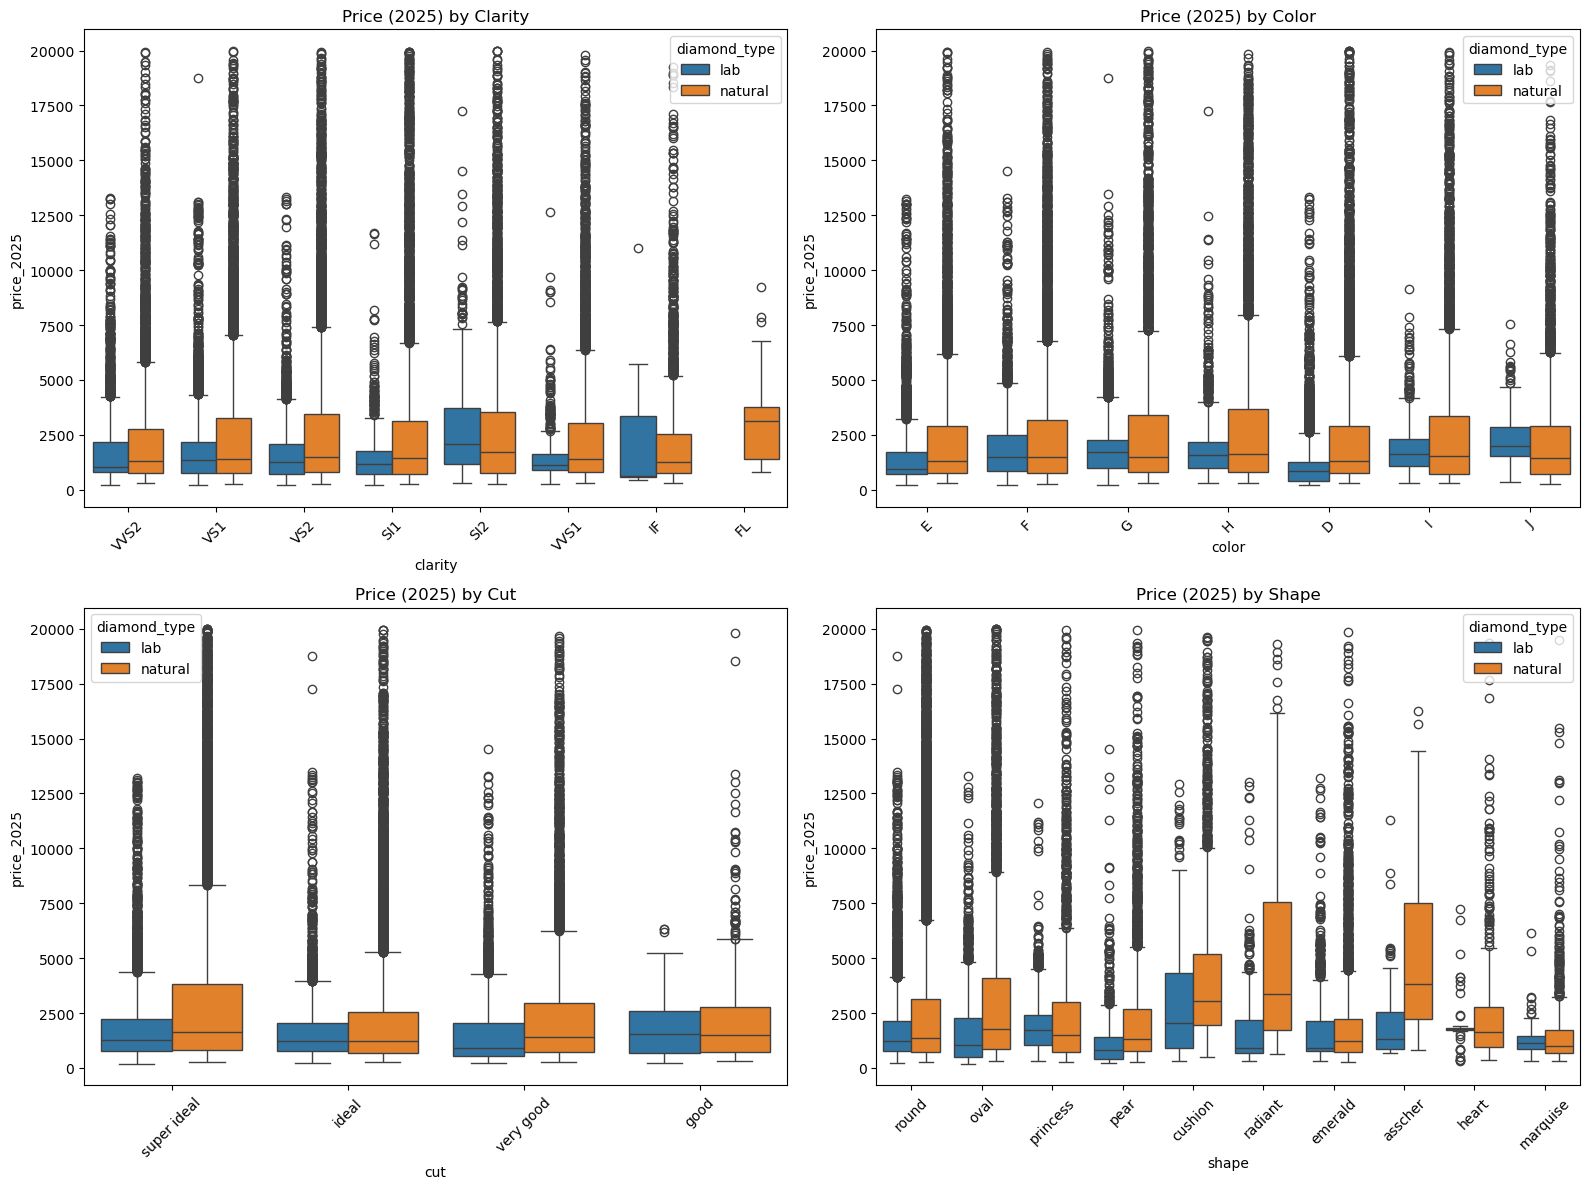

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Clarity
sns.boxplot(data=df, x='clarity', y='price_2025', hue='diamond_type', ax=axes[0, 0])
axes[0, 0].set_title('Price (2025) by Clarity')
axes[0, 0].tick_params(axis='x', rotation=45)

# Color
sns.boxplot(data=df, x='color', y='price_2025', hue='diamond_type', ax=axes[0, 1])
axes[0, 1].set_title('Price (2025) by Color')
axes[0, 1].tick_params(axis='x', rotation=45)

# Cut
sns.boxplot(data=df, x='cut', y='price_2025', hue='diamond_type', ax=axes[1, 0])
axes[1, 0].set_title('Price (2025) by Cut')
axes[1, 0].tick_params(axis='x', rotation=45)

# Shape
sns.boxplot(data=df, x='shape', y='price_2025', hue='diamond_type', ax=axes[1, 1])
axes[1, 1].set_title('Price (2025) by Shape')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

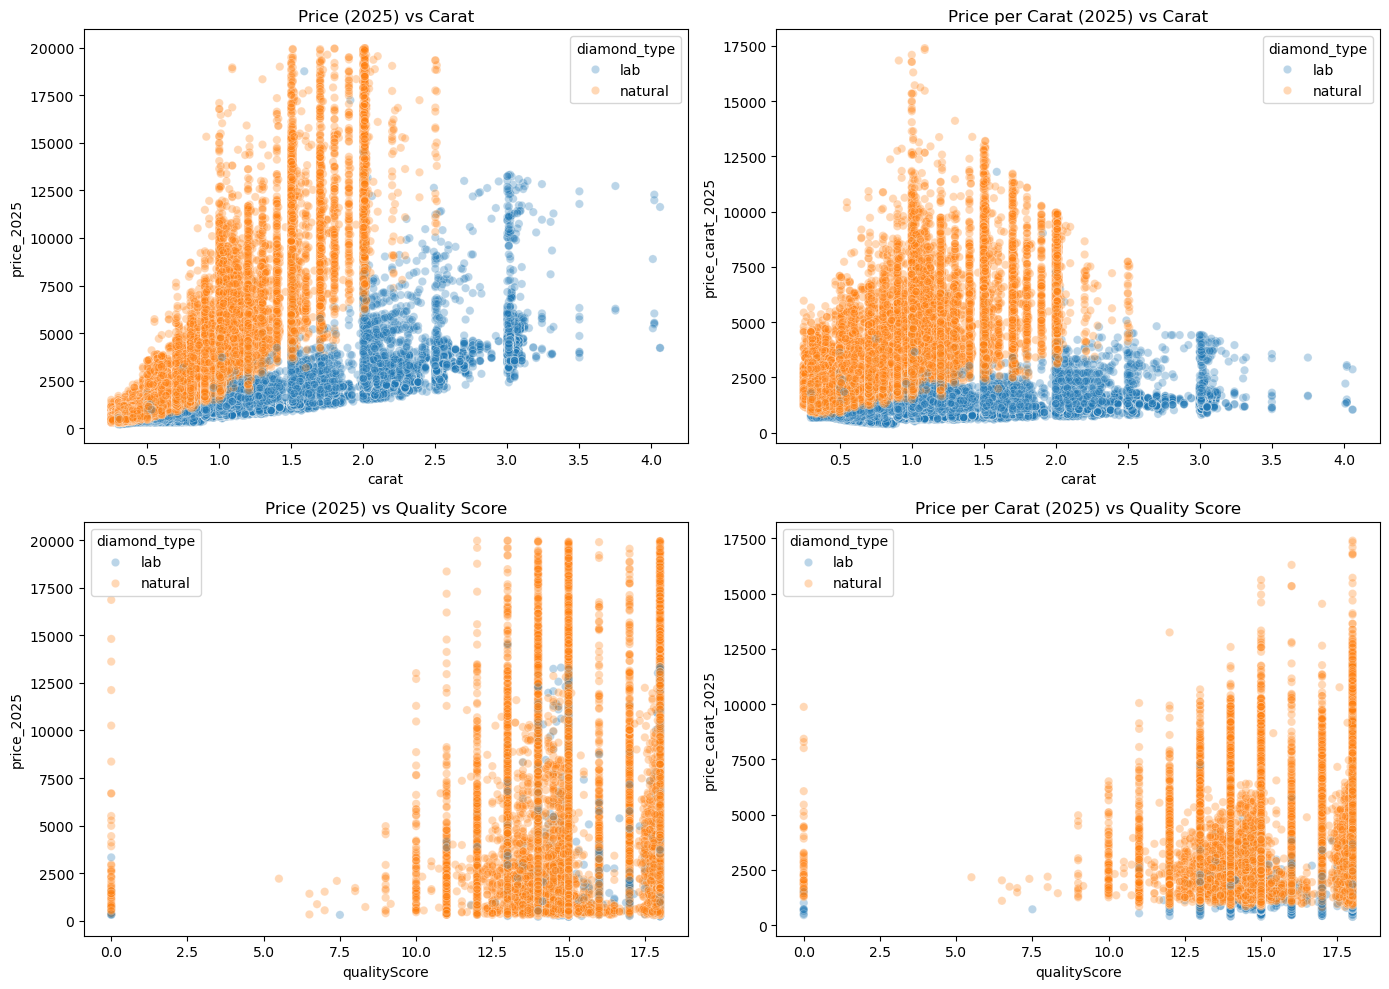

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price vs Carat
sns.scatterplot(data=df, x='carat', y='price_2025', hue='diamond_type', alpha=0.3, ax=axes[0, 0])
axes[0, 0].set_title('Price (2025) vs Carat')

# Price per Carat vs Carat
sns.scatterplot(data=df, x='carat', y='price_carat_2025', hue='diamond_type', alpha=0.3, ax=axes[0, 1])
axes[0, 1].set_title('Price per Carat (2025) vs Carat')

# Price vs Quality Score
sns.scatterplot(data=df, x='qualityScore', y='price_2025', hue='diamond_type', alpha=0.3, ax=axes[1, 0])
axes[1, 0].set_title('Price (2025) vs Quality Score')

# Price per Carat vs Quality Score
sns.scatterplot(data=df, x='qualityScore', y='price_carat_2025', hue='diamond_type', alpha=0.3, ax=axes[1, 1])
axes[1, 1].set_title('Price per Carat (2025) vs Quality Score')

plt.tight_layout()
plt.show()

Check for outliers

<Axes: xlabel='diamond_type', ylabel='price_2025'>

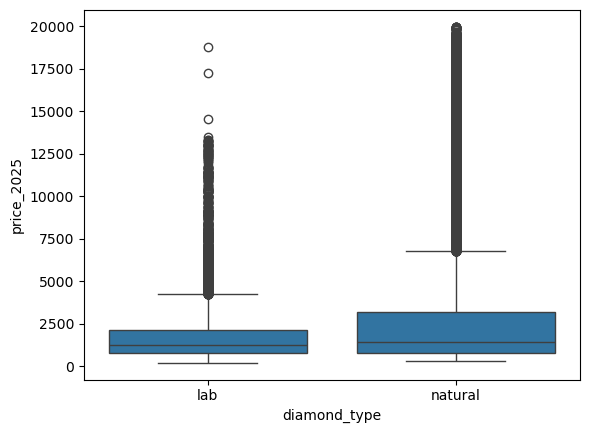

In [65]:
sns.boxplot(data=df, x='diamond_type', y='price_2025')

# Diving Deeper into Retailer Pricing Differences

Show Top Retailers

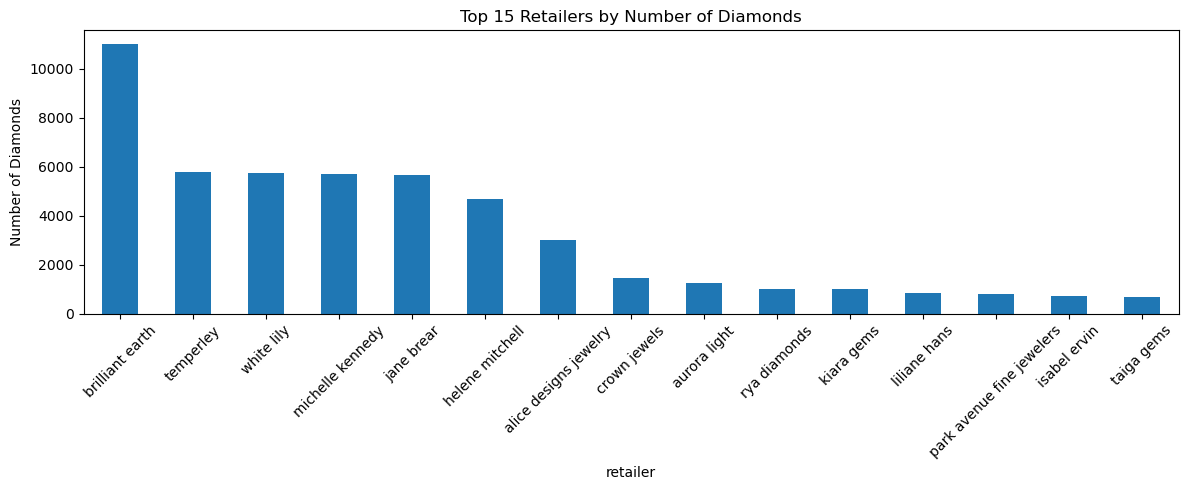

In [66]:
# Top 15 by count
top_retailers = df['retailer'].value_counts().nlargest(15)
top_retailers.plot(kind='bar', figsize=(12,5), title='Top 15 Retailers by Number of Diamonds')
plt.ylabel("Number of Diamonds")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Boxplot – Price per Carat by Retailer (Top Only)

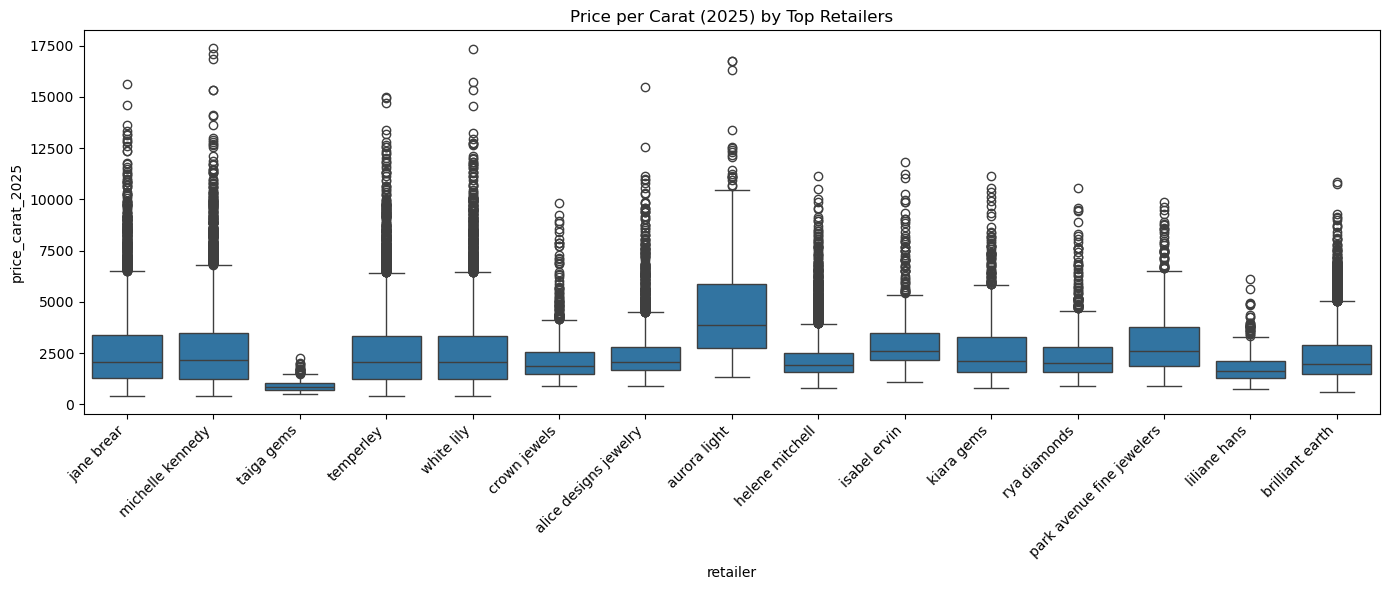

In [67]:
top_names = top_retailers.index
df_top = df[df['retailer'].isin(top_names)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_top, x='retailer', y='price_carat_2025')
plt.title("Price per Carat (2025) by Top Retailers")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Add Diamond Type (Lab vs Natural) Hue

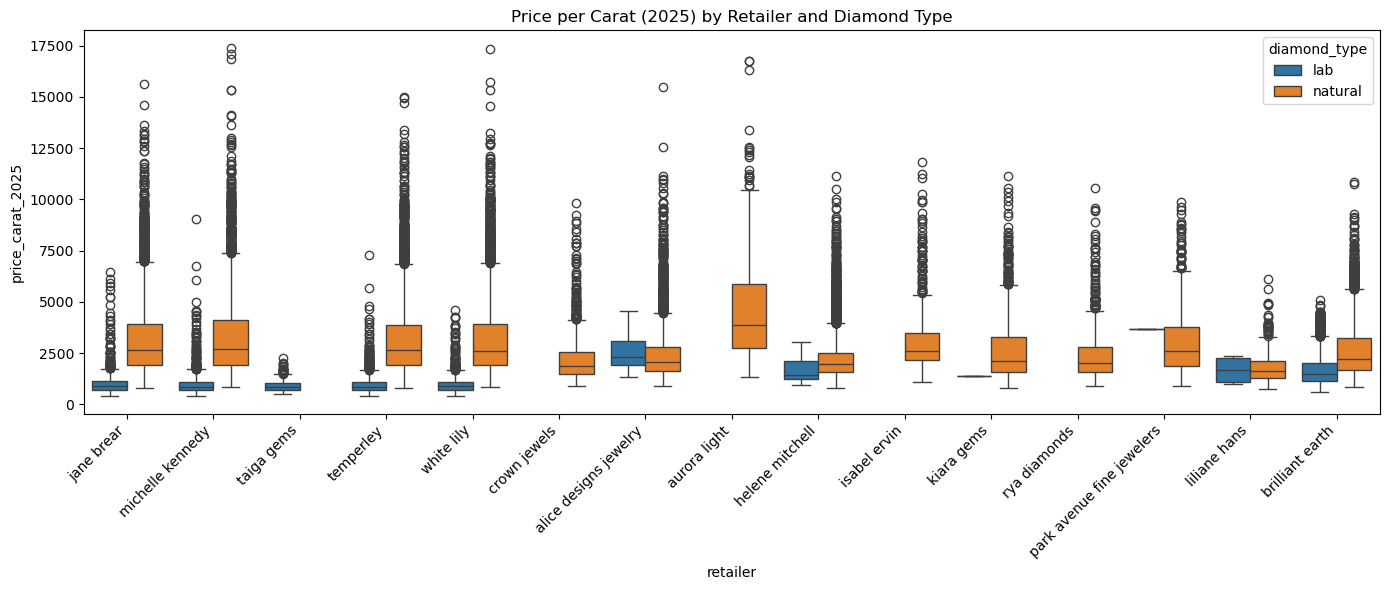

In [68]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_top, x='retailer', y='price_carat_2025', hue='diamond_type')
plt.title("Price per Carat (2025) by Retailer and Diamond Type")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Retailer Averages Table

In [69]:
# Aggregated summary
summary = df.groupby('retailer')[['price_2025', 'price_carat_2025']].agg(['mean', 'count']).sort_values(('price_2025', 'mean'), ascending=False)
summary.columns = ['avg_price', 'count', 'avg_price_per_carat', '_']
summary = summary[['avg_price', 'avg_price_per_carat', 'count']]

summary.head(10)

,avg_price,avg_price_per_carat,count
retailer,,,
herbert diamonds,8965.500000,6919.651667,6
orchid diamonds,8952.600000,5462.910000,5
monte gems,8355.285714,5449.651429,14
obelisk diamonds,8233.137931,5512.696897,29
vienna stones,8214.121495,5556.542336,107
echo stones,7270.500000,5248.594615,26
sienna diamonds,6352.000000,4141.631250,72
milo and lynn,6196.809524,4389.472857,21
brienne’s creations,6163.336493,4520.056825,211


Compare Brilliant Earth Original vs Adjusted 

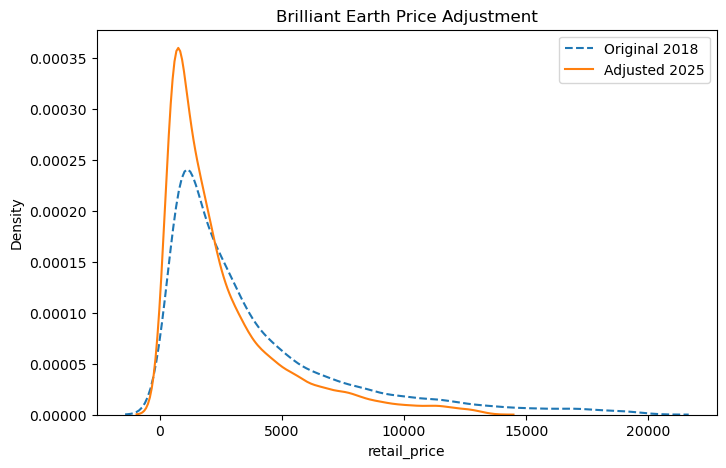

In [70]:
be_df = df[df['retailer'].str.lower().str.contains('brilliant')]

plt.figure(figsize=(8,5))
sns.kdeplot(be_df['retail_price'], label='Original 2018', linestyle='--')
sns.kdeplot(be_df['price_2025'], label='Adjusted 2025')
plt.title("Brilliant Earth Price Adjustment")
plt.legend()
plt.show()

# XGBoost model to predict diamond prices on Full Dataframe

Preprocessing

In [71]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Copy to avoid modifying original
df_model = df.copy()

# Encode all categorical columns
cat_cols = ['cut', 'color', 'clarity', 'shape', 'report', 'retailer', 'polish', 'symmetry', 'fluorescence']
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le  # store encoders in case we need to decode later

# Define features and target
features = ['carat', 'cut', 'color', 'clarity', 'shape', 'report', 'qualityScore', 
            'retailer', 'polish', 'symmetry', 'fluorescence']
X = df_model[features]
y = df_model['price_2025']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

GridSearchCV with XGBoost



In [72]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

xgb = XGBRegressor(random_state=42, verbosity=0)

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 500, 'subsample': 0.8}


Evaluate on Test Set

In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_model = grid_search.best_estimator_

# Predict using best model
y_pred = best_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


R² Score: 0.9526
MAE: 267.08
RMSE: 580.74


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Histogram of residuals

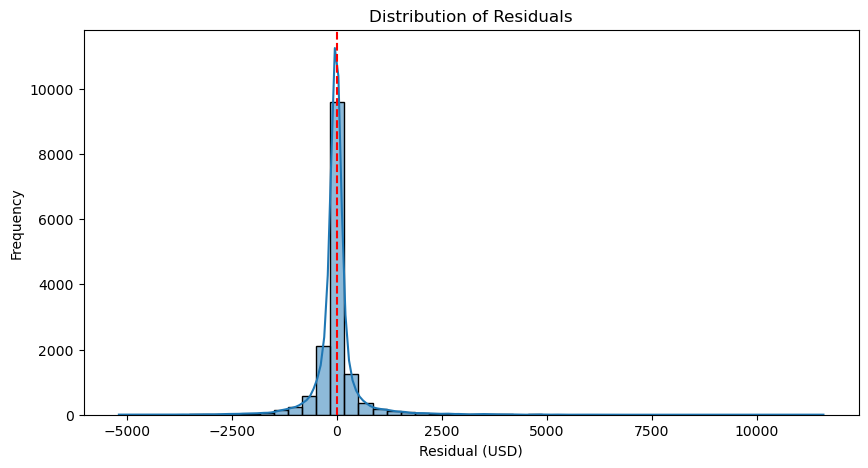

In [74]:
# Calculate residuals
residuals = y_test - y_pred

# Plot histogram of residuals
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual (USD)")
plt.ylabel("Frequency")
plt.axvline(0, color='red', linestyle='--')  # Line at zero
plt.show()

Understand how prediction errors vary with carat weight

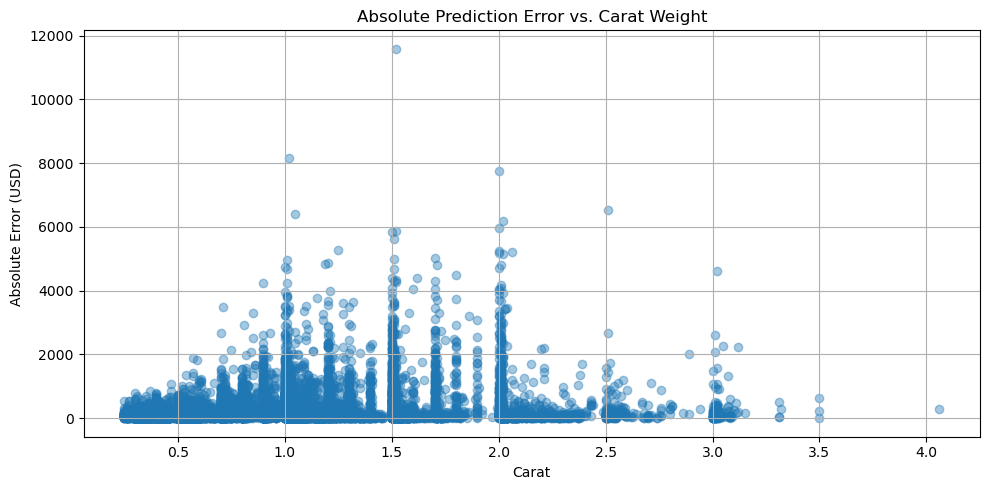

In [75]:
# Create a DataFrame for analysis
df_errors = pd.DataFrame({
    'carat': X_test['carat'],  
    'abs_error': abs(y_test - y_pred)
})
plt.figure(figsize=(10, 5))
plt.scatter(df_errors['carat'], df_errors['abs_error'], alpha=0.4)
plt.title("Absolute Prediction Error vs. Carat Weight")
plt.xlabel("Carat")
plt.ylabel("Absolute Error (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Exploring Brand Explainability

Feature Importance Plot

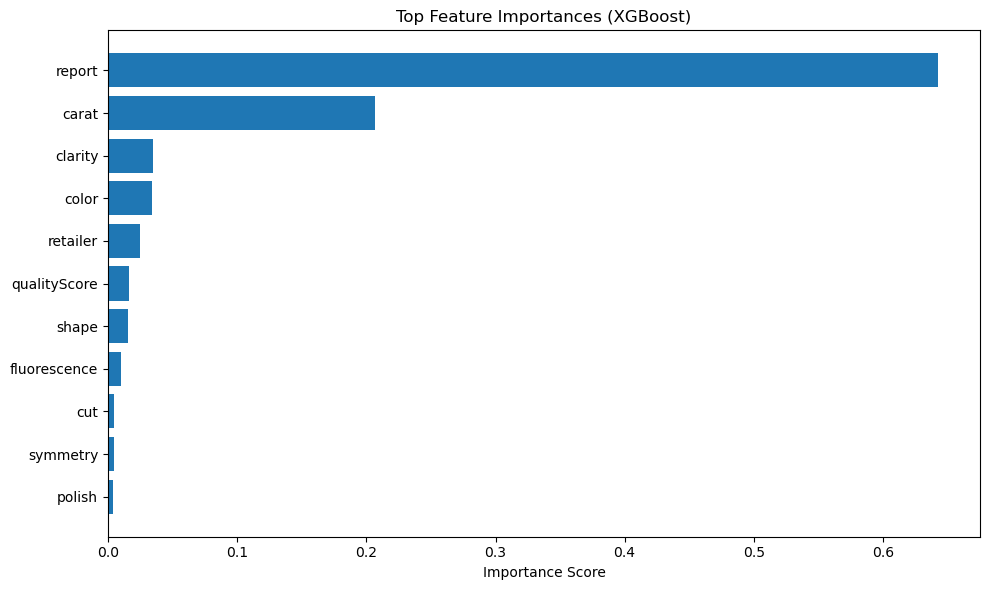

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
importance = best_model.feature_importances_
features = X.columns
sorted_idx = importance.argsort()[::-1]

top_n = min(20, len(importance))

plt.barh(range(top_n), importance[sorted_idx[:top_n]][::-1], align='center')
plt.yticks(range(top_n), features[sorted_idx[:top_n]][::-1])
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

SHAP values

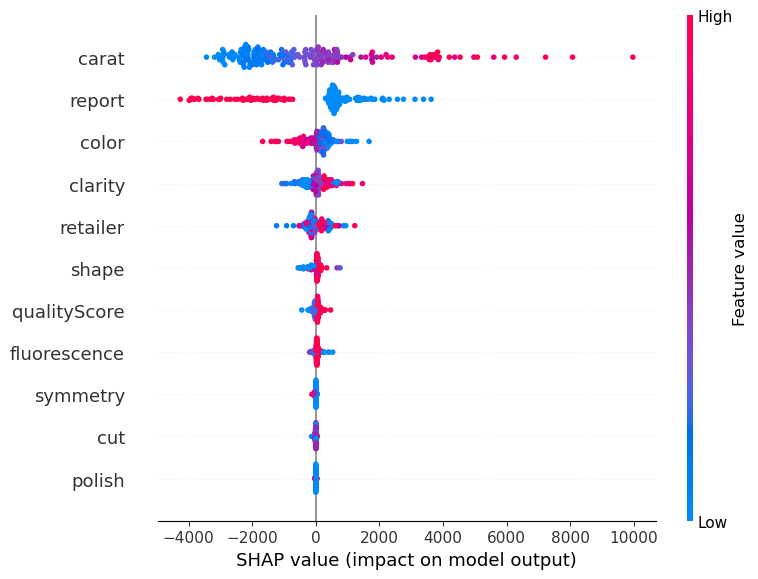

In [77]:
import shap

#Subsample
X_shap_sample = X_test.sample(200, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap_sample)
shap.summary_plot(shap_values, X_shap_sample)

# XGBoost model Full Dataframe WITHOUT retailer to predict a fair price

Preprocessing

In [78]:
df.columns


Index(['retailer', 'diamond_type', 'shape', 'polish', 'symmetry',
       'fluorescence', 'retail_price', 'price_carat', 'qualityScore',
       'qualityMaxScore', 'cut', 'color', 'clarity', 'carat', 'report',
       'price_2025', 'price_carat_2025', 'log_price', 'log_price_2025'],
      dtype='object')

In [79]:
# Drop the 'retailer' column
df_no_retailer = df.drop(columns=['retailer'])

# Group by all features except the y variable
features_fair = ['carat', 'cut', 'color', 'clarity', 'shape', 'report', 'qualityScore', 'polish', 'symmetry', 'fluorescence']

df_fair = df_no_retailer.groupby(features_fair, as_index=False)['price_2025'].mean()

# Combine df_fair and df to encode together(to predict the fair price in each row of df using the model we creatte wuth df_fair)
combined = pd.concat([df_fair[features_fair], df[features_fair]], axis=0)

# Encode all object columns
for col in combined.select_dtypes(include='object').columns:
    combined[col] = combined[col].astype('category').cat.codes

# Split back into encoded df_fair and df
df_fair[features_fair] = combined.iloc[:len(df_fair)][features_fair].values
df[features_fair] = combined.iloc[len(df_fair):][features_fair].values

# Split Train/Test
X_fair = df_fair[features_fair]
y_fair = df_fair['price_2025']

X_train_fair, X_test_fair, y_train_fair, y_test_fair = train_test_split(
    X_fair, y_fair, test_size=0.2, random_state=100
)

GridSearchCV for the Fair Model (without retailer)

In [80]:

#Define Parameter Grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

#Set Up GridSearch
xgb_fair = XGBRegressor(random_state=42, verbosity=0)

grid_fair = GridSearchCV(
    estimator=xgb_fair,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit the GridSearch
grid_fair.fit(X_train_fair, y_train_fair)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [4, 6, 8],
                         'n_estimators': [100, 200, 500],
                         'subsample': [0.8, 1.0]},
             scoring='neg_root_mean_squared_error', verbose=1)

Evaluate on Test Set

In [81]:
# Review Best Params + Evaluate on Test Set

best_fair_model = grid_fair.best_estimator_

print("Best Params (Fair Model):", grid_fair.best_params_)

# Evaluate
y_pred_fair = best_fair_model.predict(X_test_fair)

print("Fair Model R²:", r2_score(y_test_fair, y_pred_fair))
print("Fair Model MAE:", mean_absolute_error(y_test_fair, y_pred_fair))
print("RMSE:", mean_squared_error(y_test_fair, y_pred_fair, squared=False))

Best Params (Fair Model): {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}
Fair Model R²: 0.9252014519645122
Fair Model MAE: 436.5229420038014
RMSE: 793.6904399269749


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Distribution of residuals

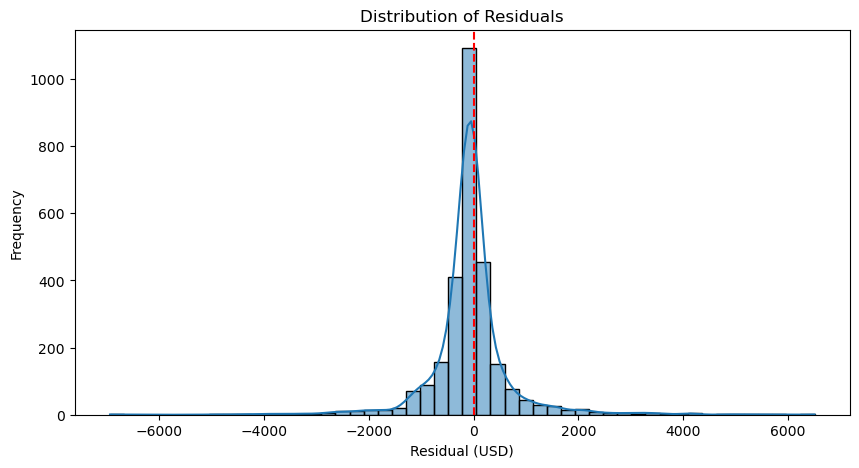

In [82]:
# Calculate residuals
residuals = y_test_fair - y_pred_fair

# Plot histogram of residuals
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual (USD)")
plt.ylabel("Frequency")
plt.axvline(0, color='red', linestyle='--') 
plt.show()

Feature Importance Plot

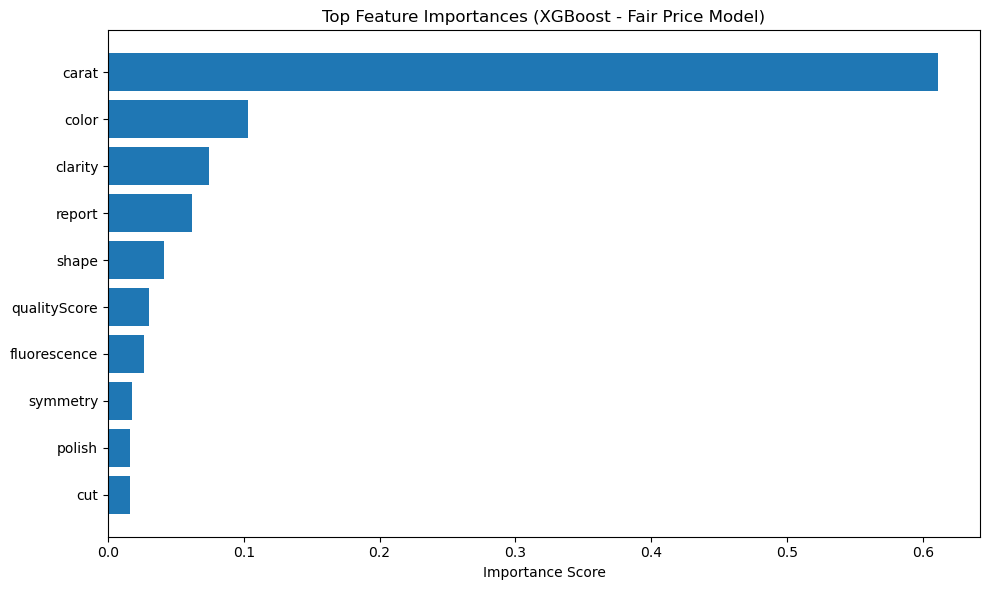

In [83]:

# Use the model trained on df_fair
importance = best_fair_model.feature_importances_
features = X_fair.columns
sorted_idx = importance.argsort()[::-1]
top_n = min(20, len(importance))

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), importance[sorted_idx[:top_n]][::-1], align='center')
plt.yticks(range(top_n), features[sorted_idx[:top_n]][::-1])
plt.title("Top Feature Importances (XGBoost - Fair Price Model)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

SHAP values

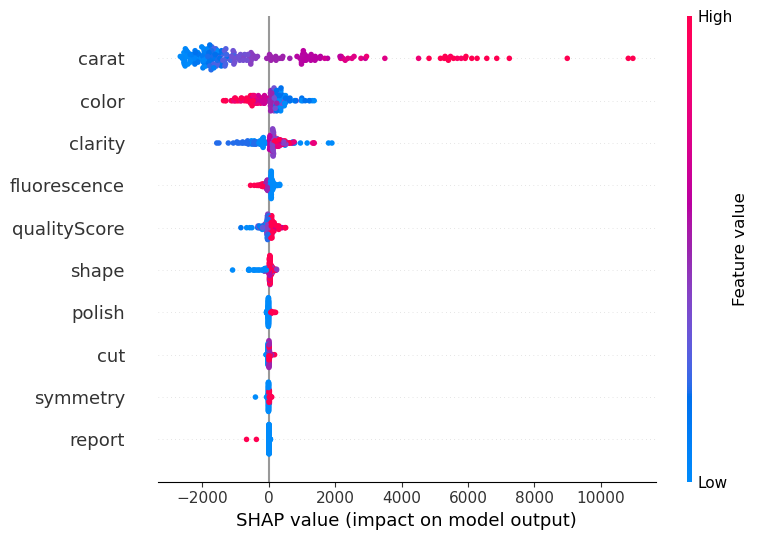

In [84]:

# Subsample for efficiency
X_shap_sample = X_test_fair.sample(200, random_state=42)

# SHAP explainer and summary plot
explainer = shap.TreeExplainer(best_fair_model)
shap_values = explainer.shap_values(X_shap_sample)
shap.summary_plot(shap_values, X_shap_sample)

# Compare Model with Retail Prices

In [85]:
df

,retailer,diamond_type,shape,polish,symmetry,fluorescence,retail_price,price_carat,qualityScore,qualityMaxScore,cut,color,clarity,carat,report,price_2025,price_carat_2025,log_price,log_price_2025
0,avignon diamonds,lab,9.0,0.0,0.0,-1.0,2842.00,1359.810000,18.000000,18.0,2.0,1.0,7.0,2.09,1.0,2842.00,1359.81,7.952615,7.952615
1,cirrus gems,lab,9.0,0.0,0.0,-1.0,2797.00,1338.280000,18.000000,18.0,2.0,1.0,7.0,2.09,1.0,2797.00,1338.28,7.936660,7.936660
2,ember star,lab,9.0,0.0,0.0,-1.0,2794.11,1336.890000,18.000000,18.0,2.0,1.0,7.0,2.09,1.0,2794.11,1336.89,7.935627,7.935627
3,jane brear,lab,9.0,0.0,0.0,-1.0,2805.00,1342.110000,18.000000,18.0,2.0,1.0,7.0,2.09,1.0,2805.00,1342.11,7.939515,7.939515
4,kiyo,lab,9.0,0.0,0.0,-1.0,2789.00,1334.450000,18.000000,18.0,2.0,1.0,7.0,2.09,1.0,2789.00,1334.45,7.933797,7.933797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75029,brilliant earth,natural,9.0,0.0,0.0,-1.0,4258.33,5193.085366,18.000000,18.0,2.0,3.0,7.0,0.82,0.0,2847.21,3472.21,7.954446,7.954446
75030,brilliant earth,natural,2.0,0.0,0.0,-1.0,2070.00,3696.428571,15.000000,15.0,1.0,0.0,1.0,0.56,0.0,1384.05,2471.51,7.233492,7.233492
75031,brilliant earth,natural,9.0,0.0,2.0,1.0,2832.31,4046.157143,14.363636,18.0,3.0,2.0,5.0,0.70,0.0,1893.74,2705.35,7.546837,7.546837
75032,brilliant earth,natural,1.0,0.0,0.0,-1.0,780.00,1560.000000,15.000000,15.0,2.0,5.0,2.0,0.50,0.0,521.52,1043.05,6.258663,6.258663


In [86]:
# create new column with predictions
df['fair_price'] = best_fair_model.predict(df[features_fair])


# Calculate Price Differences (Retailer Price vs Model Price)
df['markup_vs_fair'] = df['price_2025'] - df['fair_price']
df['markup_pct'] = 100 * df['markup_vs_fair'] / df['fair_price']

Boxplot of % Markup by Top Retailers

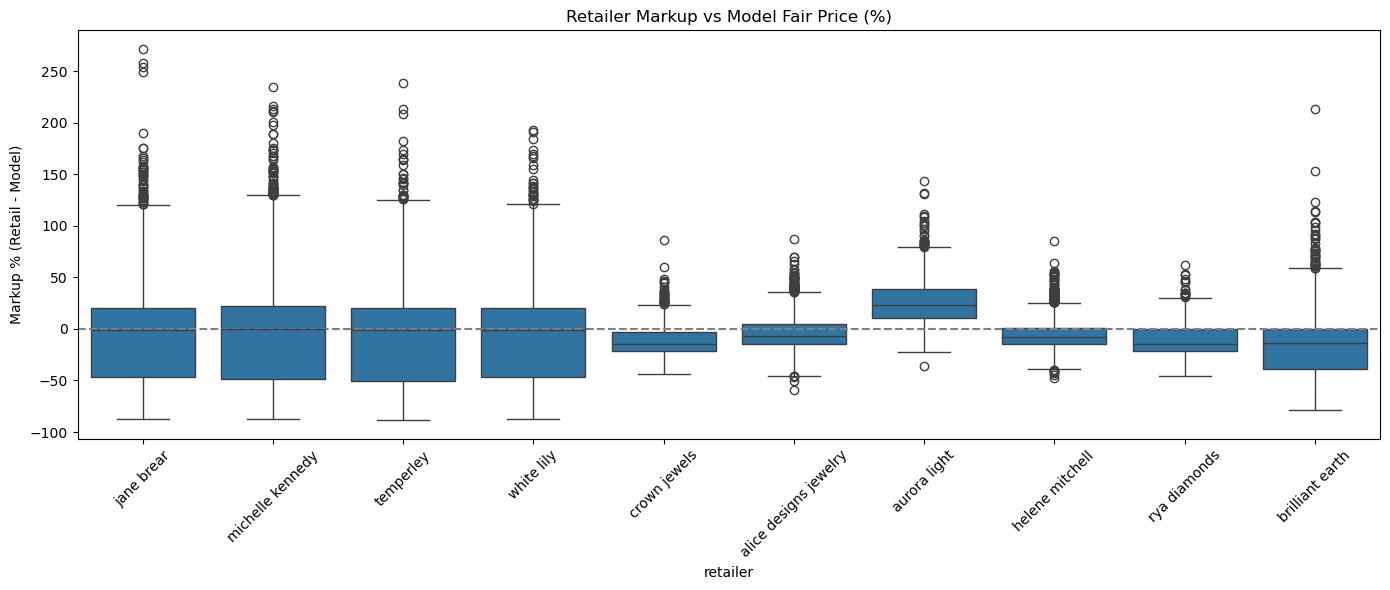

In [87]:

# Choose top 10 retailers by volume
top_retailers = df['retailer'].value_counts().nlargest(10).index
df_top = df[df['retailer'].isin(top_retailers)]

plt.figure(figsize=(14,6))
sns.boxplot(data=df_top, x='retailer', y='markup_pct')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Retailer Markup vs Model Fair Price (%)")
plt.ylabel("Markup % (Retail - Model)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Barplot of Average Markup by Retailer

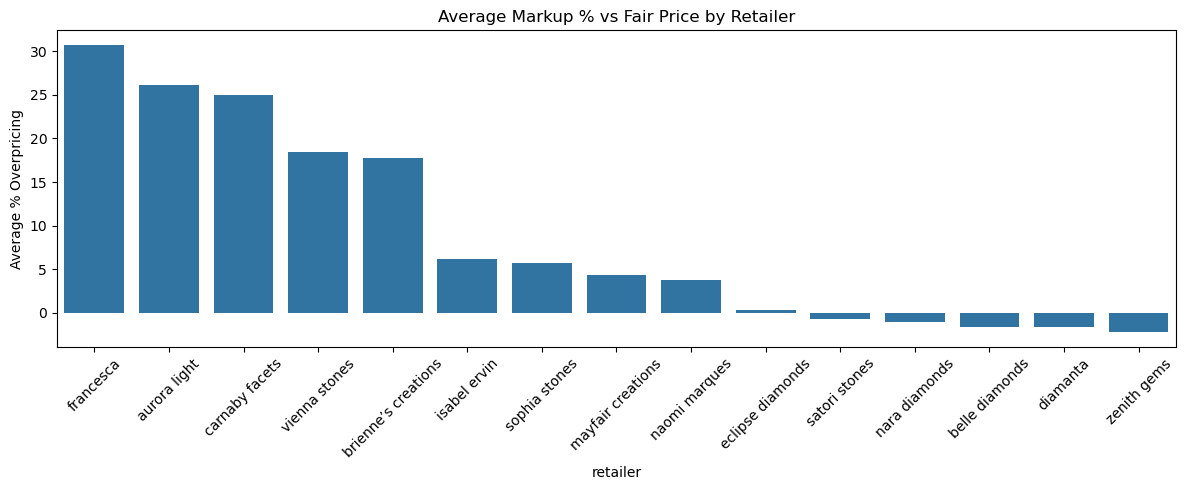

In [88]:
markup_summary = df.groupby('retailer').agg(
    count=('fair_price', 'count'),
    avg_markup=('markup_vs_fair', 'mean'),
    avg_markup_pct=('markup_pct', 'mean')
).sort_values('avg_markup_pct', ascending=False)

# Optional: filter to top 15 by count
markup_summary = markup_summary[markup_summary['count'] > 100].head(15)

plt.figure(figsize=(12,5))
sns.barplot(x=markup_summary.index, y='avg_markup_pct', data=markup_summary)
plt.title("Average Markup % vs Fair Price by Retailer")
plt.ylabel("Average % Overpricing")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Visualize Markup by Diamond Type

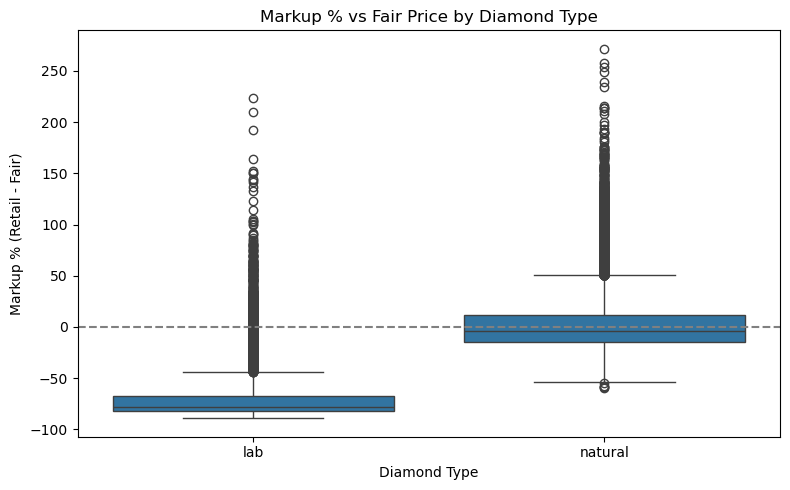

In [89]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='diamond_type', y='markup_pct')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Markup % vs Fair Price by Diamond Type")
plt.ylabel("Markup % (Retail - Fair)")
plt.xlabel("Diamond Type")
plt.tight_layout()
plt.show()

Scatterplot: Markup % vs Carat

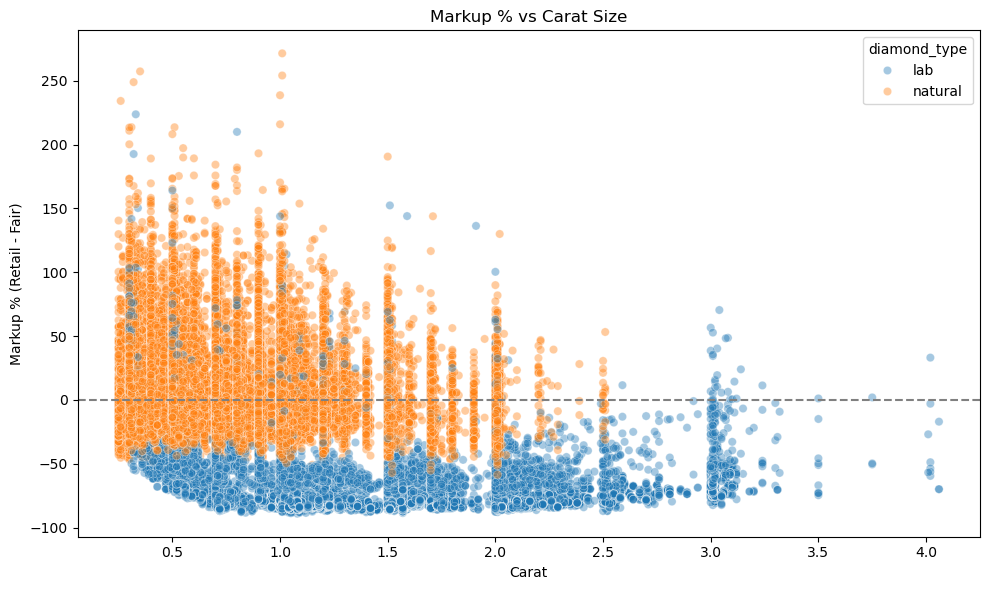

In [90]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='carat', y='markup_pct', hue='diamond_type', alpha=0.4)
plt.axhline(0, color='gray', linestyle='--')
plt.title("Markup % vs Carat Size")
plt.xlabel("Carat")
plt.ylabel("Markup % (Retail - Fair)")
plt.tight_layout()
plt.show()

## ANOVA Regression: Are average markup percentages significantly different across different retailers?

ANOVA for Markup % by Retailer

In [91]:
import scipy.stats as stats


# Get top 10 retailers
top_retailers = df['retailer'].value_counts().nlargest(10).index
df_anova = df[df['retailer'].isin(top_retailers)]

# Group markup % by retailer
groups = [group['markup_pct'].dropna() for name, group in df_anova.groupby('retailer')]

# Run ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 205.57841951723734
p-value: 0.0


The p-value is 0, which means the probability that all retailers have the same average markup % is nonexistent.

Markup % by Diamond Type

In [92]:
# Split markup % by diamond type
lab = df[df['diamond_type'] == 'lab']['markup_pct'].dropna()
nat = df[df['diamond_type'] == 'natural']['markup_pct'].dropna()

# Since there are only 2 groups, you could also use t-test:
t_stat, p_val = stats.ttest_ind(lab, nat, equal_var=False)

print("T-test statistic:", t_stat)
print("p-value:", p_val)

T-test statistic: -400.4506450888688
p-value: 0.0


The p-value is 0, so the difference in average markup between lab-grown and natural diamonds is statistically significant.

Tukey’s Test on markup_pct by Retailer

In [93]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Prepare the input data
df_tukey = df[df['retailer'].isin(top_retailers)][['retailer', 'markup_pct']].dropna()

# Run Tukey's HSD test
tukey = pairwise_tukeyhsd(
    endog=df_tukey['markup_pct'],     # The data
    groups=df_tukey['retailer'],      # The group labels
    alpha=0.05                        # Significance level
)

print(tukey)

              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
        group1             group2      meandiff p-adj   lower    upper   reject
-------------------------------------------------------------------------------
alice designs jewelry     aurora light  30.1219    0.0   26.063  34.1809   True
alice designs jewelry  brilliant earth -13.9436    0.0 -16.4357 -11.4515   True
alice designs jewelry     crown jewels  -7.1105    0.0 -10.9916  -3.2294   True
alice designs jewelry  helene mitchell  -1.9182 0.4967  -4.7501   0.9137  False
alice designs jewelry       jane brear  -2.8656 0.0312  -5.6007  -0.1306   True
alice designs jewelry michelle kennedy  -0.4882 0.9999  -3.2204    2.244  False
alice designs jewelry     rya diamonds   -6.628 0.0001 -11.0058  -2.2502   True
alice designs jewelry        temperley  -3.7602 0.0005   -6.484  -1.0363   True
alice designs jewelry       white lily  -3.7475 0.0006  -6.4739  -1.0211   True
         aurora light  brilliant earth -

#  Investigating Lab-Grown and Natural Diamonds Separately

Preprocessing

In [94]:
def preprocess_for_xgb(df_subset):
    # Fill missing
    for col in ['polish', 'symmetry', 'fluorescence', 'report']:
        df_subset[col] = df_subset[col].fillna('Unknown')
    
    # Encode object columns
    for col in df_subset[features_fair].select_dtypes(include='object').columns:
        df_subset[col] = df_subset[col].astype('category').cat.codes
    
    return df_subset

df_lab = preprocess_for_xgb(df_lab)
df_nat = preprocess_for_xgb(df_natural)

Train-test split

In [95]:
# Train-test split
X_lab = df_lab[features_fair]
y_lab = df_lab['price_2025']

X_train_lab, X_test_lab, y_train_lab, y_test_lab = train_test_split(X_lab, y_lab, test_size=0.2, random_state=100)

X_nat = df_nat[features_fair]
y_nat = df_nat['price_2025']

X_train_nat, X_test_nat, y_train_nat, y_test_nat = train_test_split(X_nat, y_nat, test_size=0.2, random_state=100)


Perform Grid Search

In [96]:
#Define the parameter grid

param_grid = {
    'max_depth': [4, 6, 8, 10],
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.05, 0.1, 0.2]
}

# Grid Search for Lab-Grown Diamonds

grid_lab = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    scoring='neg_mean_absolute_error',
    cv=3
)

grid_lab.fit(X_train_lab, y_train_lab)
best_model_lab = grid_lab.best_estimator_
print("✅ Best parameters for lab-grown diamonds:")
print(grid_lab.best_params_)

# Grid Search for Natural Diamonds
grid_nat = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    scoring='neg_mean_absolute_error',
    cv=3
)

grid_nat.fit(X_train_nat, y_train_nat)
best_model_nat = grid_nat.best_estimator_
print("✅ Best parameters for natural diamonds:")
print(grid_nat.best_params_)

✅ Best parameters for lab-grown diamonds:
{'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200}
✅ Best parameters for natural diamonds:
{'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500}


In [97]:
from pathlib import Path
from xgboost import XGBRegressor
import pickle

# ensure folder exists
Path("models").mkdir(exist_ok=True)

# SAVE MODELS
best_model_lab.save_model("models/lab_model.json")
best_model_nat.save_model("models/natural_model.json")

print("✔ Saved XGBoost models")

# SAVE CATEGORY ENCODINGS
category_map = {}  # dict: column → {category_string: code_int}

# We must extract the codes BEFORE they were converted to integers
# So reload the cleaned dataframe BEFORE cat.codes were applied
# OR generate codes from the ordered categories
for col in features_fair:
    if col in df_lab.columns:
        # Identify categorical columns from the df BEFORE training
        if df_lab[col].dtype == "category" or df_lab[col].dtype == object:
            # Convert to category and store mapping
            temp = df_lab[col].astype("category")
            cats = list(temp.cat.categories)
            category_map[col] = {cat: code for code, cat in enumerate(cats)}

# Save mapping
with open("models/category_mapping.pkl", "wb") as f:
    pickle.dump(category_map, f)

print("✔ Saved category mappings")


# SAVE FEATURES
with open("models/features.pkl", "wb") as f:
    pickle.dump(features_fair, f)

print("✔ Saved feature list")


print("🎉 All model artifacts saved successfully!")


✔ Saved XGBoost models
✔ Saved category mappings
✔ Saved feature list
🎉 All model artifacts saved successfully!


Evaluate Both Tuned Models

In [98]:
# Lab
y_pred_lab = best_model_lab.predict(X_test_lab)
print("Lab - R²:", r2_score(y_test_lab, y_pred_lab))
print("Lab - MAE:", mean_absolute_error(y_test_lab, y_pred_lab))
print("Lab - RMSE:", mean_squared_error(y_test_lab, y_pred_lab, squared=False))

# Natural
y_pred_nat = best_model_nat.predict(X_test_nat)
print("Natural - R²:", r2_score(y_test_nat, y_pred_nat))
print("Natural - MAE:", mean_absolute_error(y_test_nat, y_pred_nat))
print("Natural - RMSE:", mean_squared_error(y_test_nat, y_pred_nat, squared=False))

Lab - R²: 0.8778610397849627
Lab - MAE: 149.2292359778658
Lab - RMSE: 424.5019439788751
Natural - R²: 0.919784949944313
Natural - MAE: 436.3193755250667
Natural - RMSE: 855.6096868124116


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


SHAP Analysis for Each Tuned Model

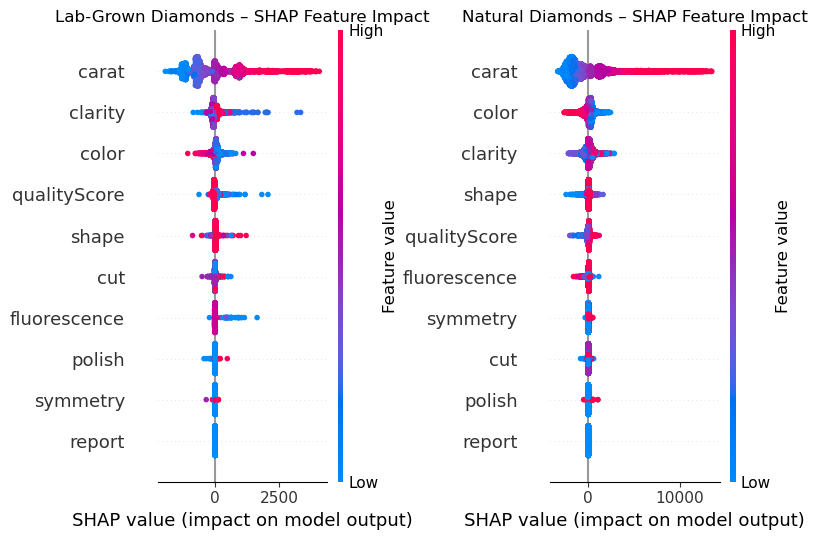

In [99]:

# Compute SHAP values
explainer_lab = shap.Explainer(best_model_lab)
shap_values_lab = explainer_lab(X_test_lab)

explainer_nat = shap.Explainer(best_model_nat)
shap_values_nat = explainer_nat(X_test_nat)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 16))

# Set SHAP to use the current axes manually
plt.sca(axes[0])
shap.plots.beeswarm(shap_values_lab, max_display=10, show=False)
axes[0].set_title("Lab-Grown Diamonds – SHAP Feature Impact")

plt.sca(axes[1])
shap.plots.beeswarm(shap_values_nat, max_display=10, show=False)
axes[1].set_title("Natural Diamonds – SHAP Feature Impact")

plt.tight_layout()
plt.show()

Side-by-Side Plot of Predicted vs. Actual Prices

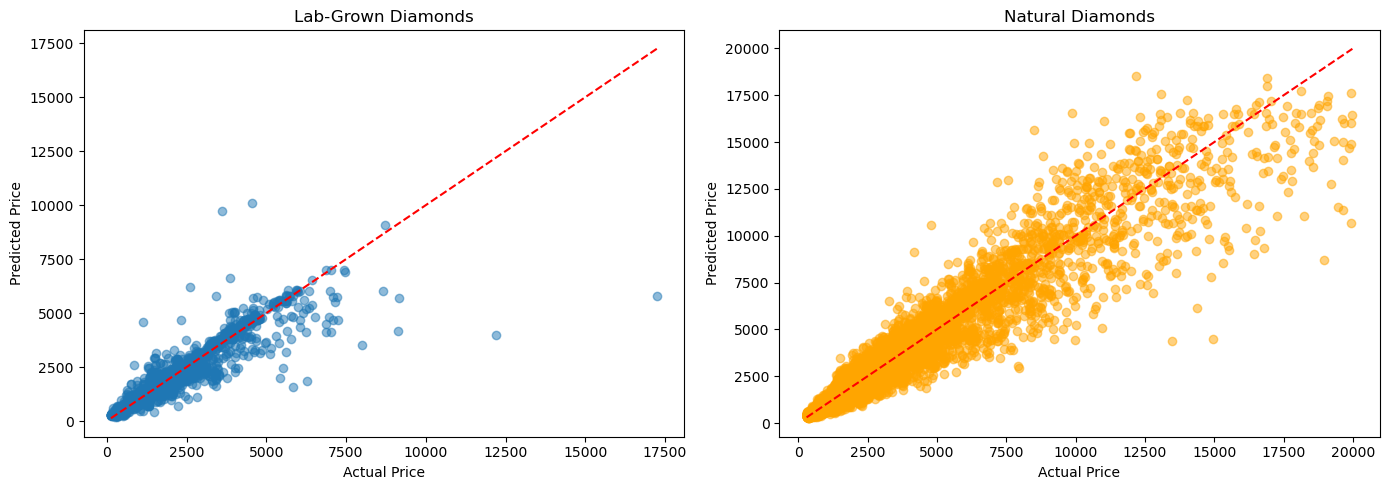

In [100]:
# Create a side-by-side comparison plot
plt.figure(figsize=(14, 5))

# Lab-grown
plt.subplot(1, 2, 1)
plt.scatter(y_test_lab, y_pred_lab, alpha=0.5)
plt.plot([y_test_lab.min(), y_test_lab.max()], [y_test_lab.min(), y_test_lab.max()], 'r--')
plt.title('Lab-Grown Diamonds')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

# Natural
plt.subplot(1, 2, 2)
plt.scatter(y_test_nat, y_pred_nat, alpha=0.5, color='orange')
plt.plot([y_test_nat.min(), y_test_nat.max()], [y_test_nat.min(), y_test_nat.max()], 'r--')
plt.title('Natural Diamonds')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.tight_layout()
plt.show()